from age_depth_harmonica code, made sept 8

In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import pygmt

In [2]:
df = pd.read_csv('..\\..\\created_data\\lola_grav_age_q_z_bath.csv', header=0)

print(df.head())

         long        lat         FA        age  q_ihfc       q_ps    q_stein  \
0 -133.000003  37.983334 -20.522749  33.939312    19.0  81.209931  87.542442   
1 -133.000003  38.100001 -24.824638  33.939312    19.0  81.209931  87.542442   
2 -133.000003  38.216667 -31.192137  33.939312    19.0  81.209931  87.542442   
3 -133.000003  38.333334 -38.186611  33.939312    19.0  81.209931  87.542442   
4 -133.000003  38.450001 -32.169643  33.939312    19.0  81.209931  87.542442   

          ps_z        stein_z   bathy  
0  4539.010966  423035.068147 -5025.0  
1  4539.010966  423035.068147 -5037.0  
2  4539.010966  423035.068147 -5054.0  
3  4539.010966  423035.068147 -5046.0  
4  4539.010966  423035.068147 -4910.0  


now for pars-scl, we get depth from formula 21 and heat flow from formula 23... and for stein x2 we get depth and heat flow from pg 126

In [3]:
# ihfc_qt = []
# sqrt_age = []
# ps_qt = []
# dt_ps = []
# stein_qt = []
# dt_stein = []

# # ihfc
# for q in df['q']:
#     ihfc_qt.append(q*0.0238846)  # mW/m^2 --> μcal/cm^2*s

# # pars-scl
# for a in df['age']:
#     sqrt_age.append(a**(0.5))
#     dt_ps.append(2500 + 350*(a**(0.5)))
#     ps_qt.append(11.3/a**(0.5))

# # stein x2
# for a in df['age']:
#     dt_stein.append(2600 + 365*(a**0.5))
#     stein_qt.append((510/a**(0.5))*0.0239)  # mW/m^2 --> μcal/cm^2*s

# print(f'pars-scl depth: {dt_ps[0:11]}\nstein depth: {dt_stein[0:11]}')
# # print(f'sqrt(age): {sqrt_age[:2]}')
# # print(f'ihfc heat flow: {ihfc_qt[:2]}, pars-scl heat flow: {ps_qt[:2]}, stein heat flow: {stein_qt[:2]}')

In [4]:
# fig0, ax0 = plt.subplots(figsize=(12, 6))

# ax0.scatter(df['age'], df['q_ihfc'], marker='o',color='red', s=5, label='IHFC')
# ax0.scatter(df['age'], df['q_ps'], marker='^', color='blue', s=5, label='P&S')
# ax0.scatter(df['age'], df['q_stein'], marker='^', color='green', s=5, label='Stein')
# # ax0.set_ylim(0, 120)
# ax0.set_xlabel('Age (Ma)')
# ax0.set_ylabel('Heat Flow (μcal/cm^2*s)')
# ax0.set_title('Combined Heat Flow Data')
# ax0.set_axisbelow(True)

# plt.grid(alpha=0.5)
# plt.legend()
# plt.show()

# tesseroid time!
Now we are going to plot the gravity as a tesseroid (6 bounds: west, east, south, north, bottom, top)

In [5]:
import boule as bl
import verde as vd
import harmonica as hm
from numba import njit

GRS80 (Geodetic Reference System 1980) vs WGS84 (World Geodetic System 1984) --> '...if you're using GPS coordinates or anything referenced to satellite positioning, you're technically in WGS84; if you're doing pure geodetic/gravity theory work, GRS80 is the traditional standard.'

In [6]:
ellipsoid = bl.WGS84
mean_radius = bl.WGS84.mean_radius  # from boule, earth radius for an ellipsoid

### option 1: using gygmt.surface, which takes df['FA'] and fills in the gaps between using interpolation to smooth the og data or residuals.

>however i am using my gravity data with alr interpolated values #goated data

[blockmedian](https://www.pygmt.org/latest/api/generated/pygmt.blockmedian.html#pygmt.blockmedian)

In [7]:
top = mean_radius - df['ps_z']  # places the top of the tesseroid at the predicted pars-scl seafloor depth
thickness = 7000  # assuming oceanic crust is 7km aka cmb
cmb = top - thickness
bottom = mean_radius - df['ps_z'] - thickness  # places the bottom of the tesseroid at predicted pars-scl seafloor depth

# region=df['long'].min(), df['long'].max(), df['lat'].min(), df['lat'].max()
region=[-130, -125, 45, 48]
spacing=0.01  # number of pnts in each S-N and W-E direction, adjust based on data density

In [8]:
# block-reduce to avoid aliasing (average points within each grid cell)
block_reduce = pygmt.blockmedian(x=df['long'], y=df['lat'], z=df['FA'],   # or whatever column you want gridded
    region=region,
    spacing=spacing)

# interpolate onto a continuous grid
grav_grid = pygmt.surface(data=block_reduce, region=region, spacing=spacing)

print(grav_grid.head())

<xarray.DataArray 'z' (y: 5, x: 5)> Size: 100B
array([[-4.5493937, -4.36881  , -4.188333 , -4.0080724, -3.828167 ],
       [-4.259336 , -4.1200643, -3.9806142, -3.8407829, -3.7003562],
       [-3.9692988, -3.8716216, -3.7735016, -3.6744382, -3.5738683],
       [-3.6793413, -3.623794 , -3.5675805, -3.5099308, -3.4499433],
       [-3.3895688, -3.3768978, -3.363394 , -3.3480725, -3.3297136]],
      dtype=float32)
Coordinates:
  * y        (y) float64 40B 45.0 45.01 45.02 45.03 45.04
  * x        (x) float64 40B -130.0 -130.0 -130.0 -130.0 -130.0
Attributes:
    Conventions:   CF-1.7
    title:         Data gridded with continuous surface splines in tension
    history:       gmt surface @GMTAPI@-S-I-D-V-T-N-000000 -G@GMTAPI@-S-O-G-G...
    description:   
    actual_range:  [nan nan]
    long_name:     z


[make_xarray_grid](https://www.fatiando.org/verde/latest/api/generated/verde.make_xarray_grid.html#verde-make-xarray-grid)

projection --> 10c: width of the map (10 centimeters)

[fig.coast](https://www.pygmt.org/latest/api/generated/pygmt.Figure.coast.html)

cmap og range: -150 to 350

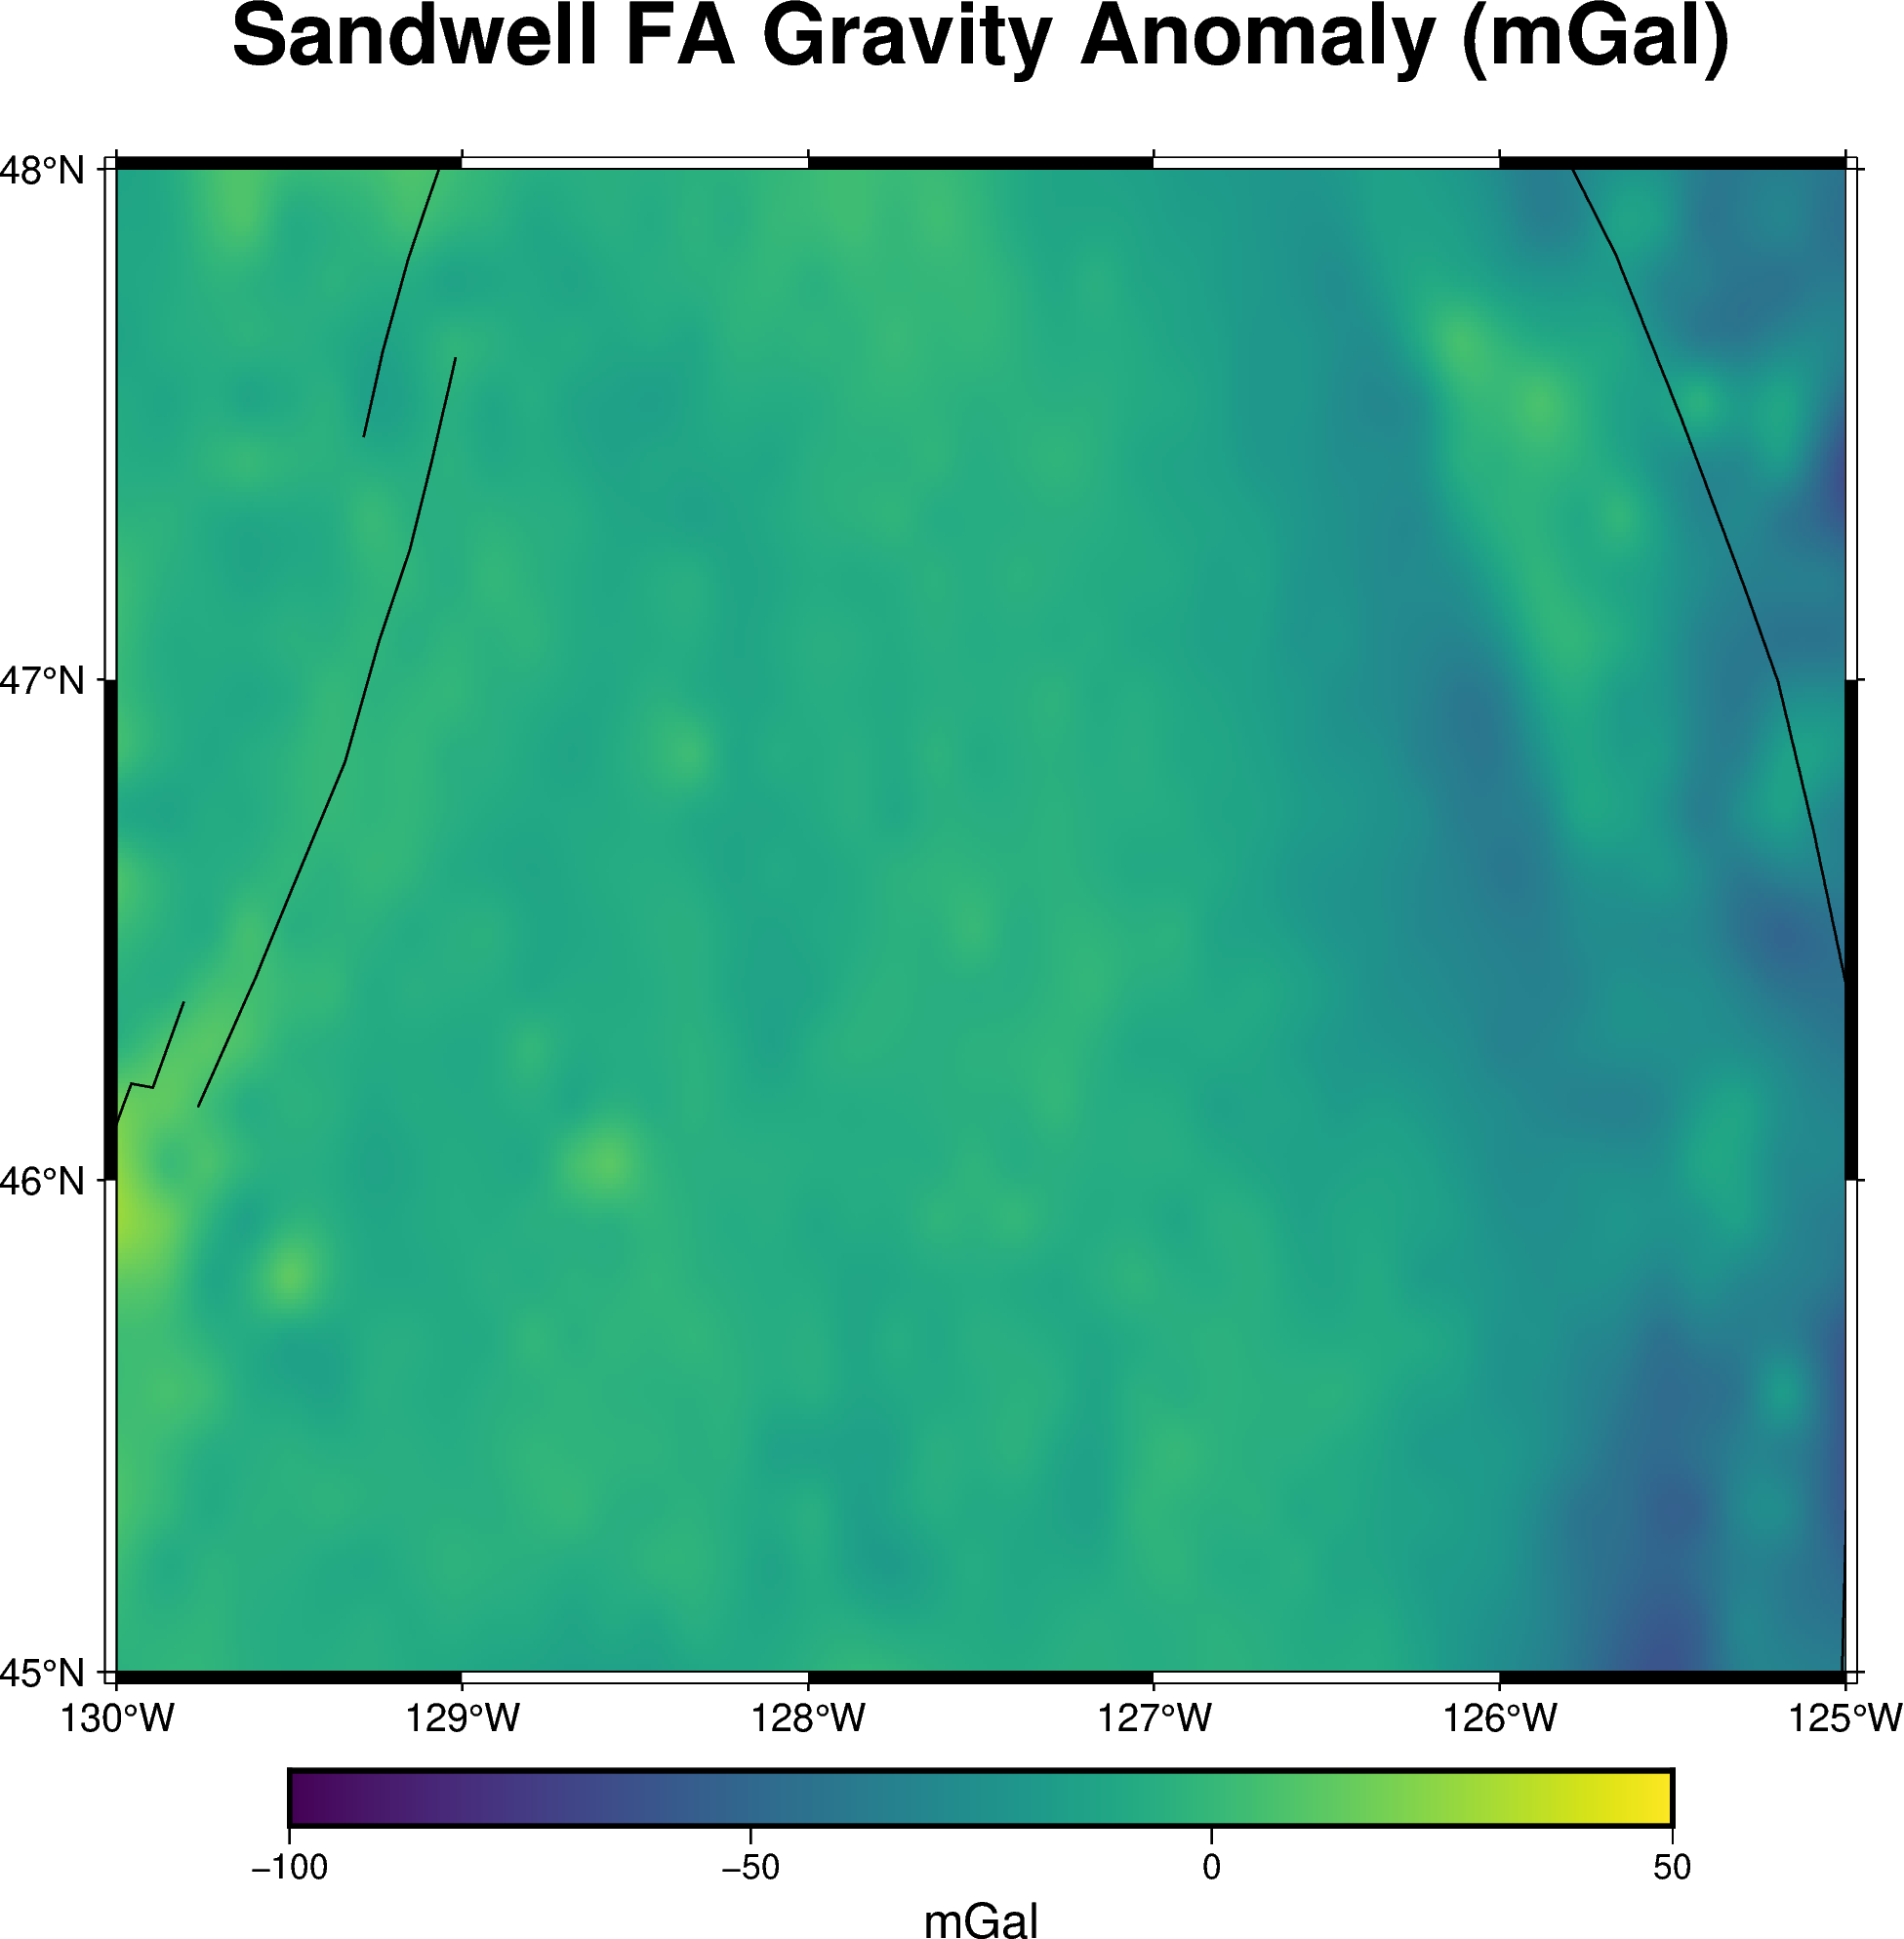

In [9]:
fig1 = pygmt.Figure()
title = 'Sandwell FA Gravity Anomaly (mGal)'

pygmt.makecpt(cmap='viridis', series=[-100, 50])  # sets the actual color range

fig1.grdimage(grid=grav_grid, cmap=True, region=region, projection='M15c', frame=['a', f'+t{title}'])
fig1.colorbar(cmap=True, frame=['a50f50', 'x+lmGal'])  # annotate every 50 mGal, tick every 50 mGal
fig1.plot(data='..\\..\\data\\Plate_Boundaries.shp\\Plate_Boundaries.shp', pen='0.5p,black')
fig1.coast(land='green', transparency=50, shorelines='0.5p,darkgreen')


fig1.savefig(f'..\\..\\figures\\jdf_grav_sept8\\FA_sp{spacing}.png', dpi=400, crop='0.5c')  # crop to put whitespace around when i save it
fig1.show()

### option 2: hm.tesseroid_gravity: forward model that computes unknown gravity from a physical model

[vd.grid_coords](https://www.fatiando.org/verde/latest/api/generated/verde.grid_coordinates.html#verde-grid-coordinates) 
and [tutorial](https://www.fatiando.org/verde/dev/tutorials/grid_coordinates.html) --> generates raw coordinate values, whereas [vd.make_xarray_grid](https://www.fatiando.org/verde/latest/api/generated/verde.make_xarray_grid.html) takes arrays and packages them into a dataset

[hm.tesseroid_gravity](https://www.fatiando.org/harmonica/latest/api/generated/harmonica.tesseroid_gravity.html) --> from hm tesseroid example but takes too long for all the data

field options:
- grav potential: potential [J/kg]
- downward acc: g_z [mGal --> 10e-5 m/s^2]

In [10]:
bottom = ellipsoid.mean_radius - 10e3
top = ellipsoid.mean_radius

In [11]:
@njit
def density(radius):
    """Linear density function"""
    top = mean_radius
    bottom = mean_radius - 10e3
    density_top = 2670
    density_bottom = 3000
    slope = (density_top - density_bottom) / (top - bottom)
    return slope * (radius - bottom) + density_bottom

extra coords creates an extra coordinate that the same shape as the coordinate grid with a constant value (in this case, radius)

In [12]:
coords = vd.grid_coordinates(
    region=region,
    spacing=spacing,
    extra_coords=mean_radius)

tesseroid = ([region[0] + 1, region[1] - 3, region[2] + 1, region[3] - 1, 
                bottom, top])

gravity = hm.tesseroid_gravity(coords, tesseroid, density, field='g_z')

In [13]:
grid = vd.make_xarray_grid(coords, gravity, data_names='gravity', extra_coords_names='extra')

In [14]:
# df['gravity'] = gravity
# df['residual'] = df['FA'] - df['gravity']

# print(df['gravity'].head())
# print(df['residual'].head())

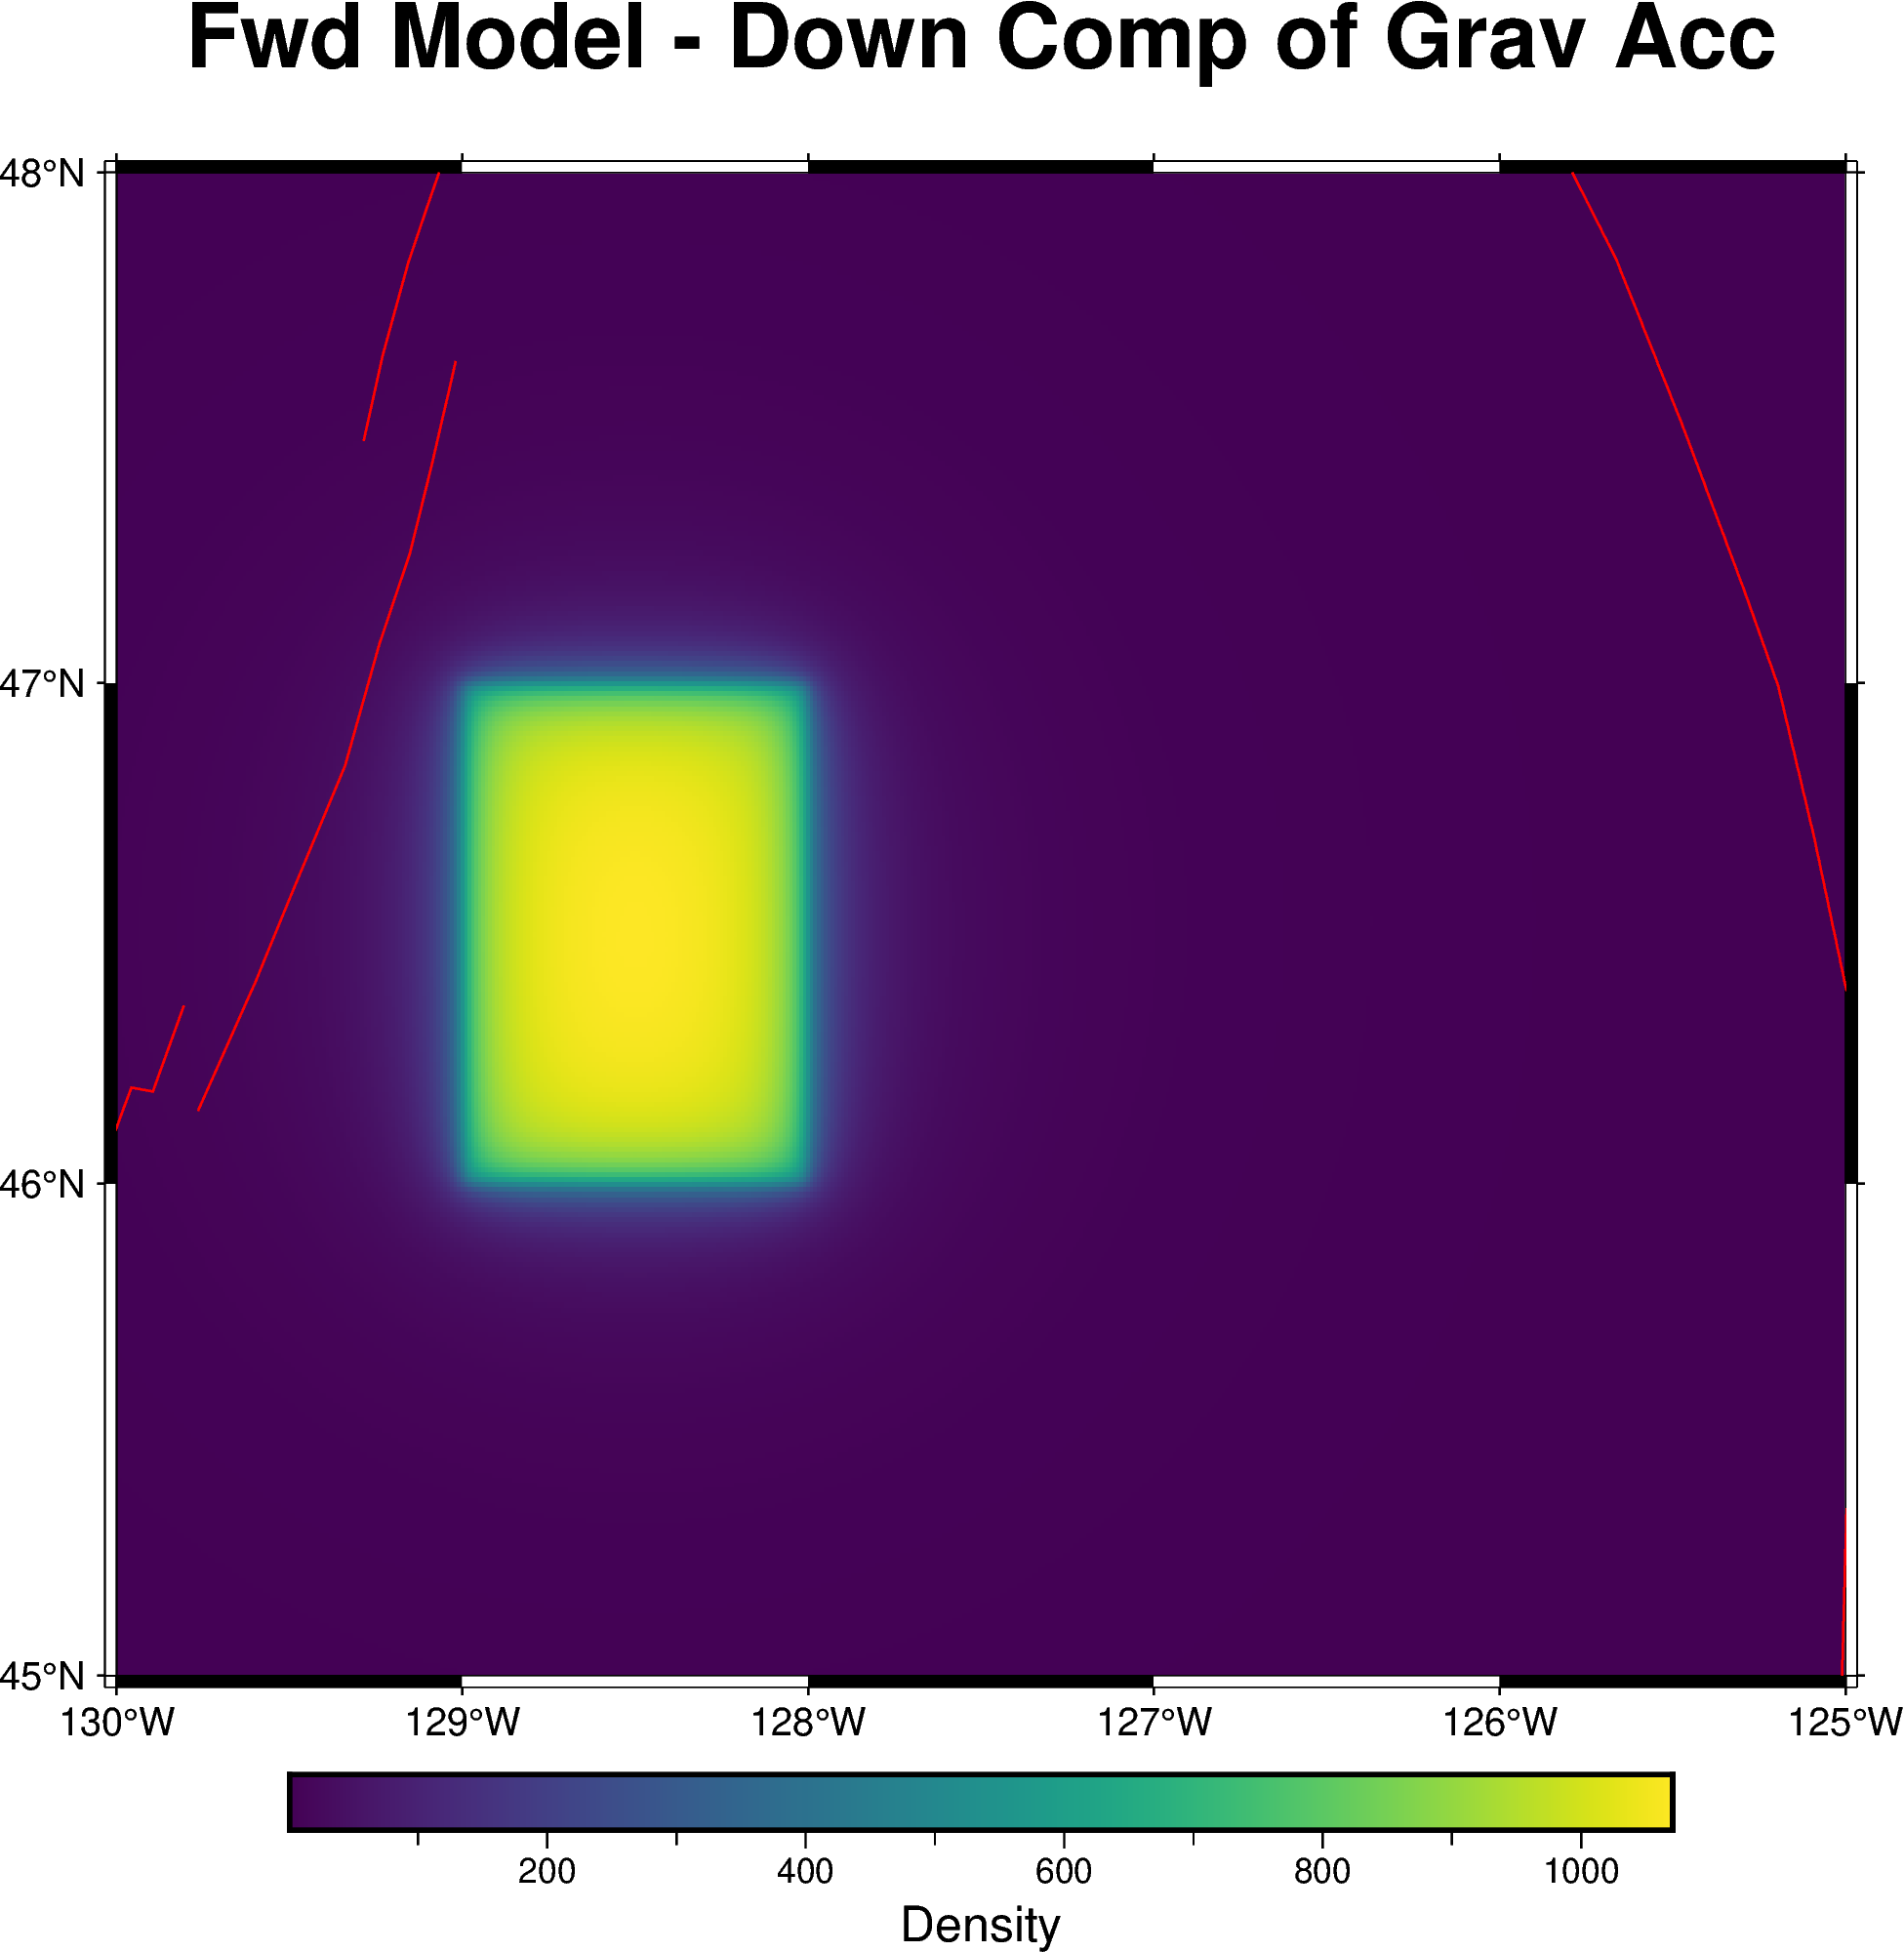

In [15]:
fig = pygmt.Figure()
title = 'Fwd Model - Down Comp of Grav Acc'
with pygmt.config(FONT_TITLE='22p'):
   fig.grdimage(
      region=region,
      projection='M15c',
      grid=grid.gravity,
      frame=['a', f'+t{title}'],
      cmap='viridis',
   )

fig.plot(data='..\\..\\data\\Plate_Boundaries.shp\\Plate_Boundaries.shp', pen='0.5p,red')
fig.coast(land='green', transparency=50, shorelines='0.5p,darkgreen')

fig.colorbar(cmap=True, frame=['a200f100', 'x+lDensity'])

fig.savefig(f'..\\..\\figures\\jdf_grav_sept8\\fwd_model_acc_sp{spacing}.png', dpi=400, crop='0.5c')  # crop to put whitespace around when i save it
fig.show()